In [12]:
import tensorflow as tf
import matplotlib.pyplot as plt

Found 1400 files belonging to 20 classes.
Found 400 files belonging to 20 classes.
Epoch 1/10


c:\Users\kangg\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.0562 - loss: 3.1288 - val_accuracy: 0.1225 - val_loss: 2.8400
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 39s 880ms/step - accuracy: 0.1292 - loss: 2.8078 - val_accuracy: 0.1750 - val_loss: 2.6391
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 39s 875ms/step - accuracy: 0.2133 - loss: 2.6013 - val_accuracy: 0.1900 - val_loss: 2.6533
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 39s 880ms/step - accuracy: 0.2862 - loss: 2.3133 - val_accuracy: 0.1775 - val_loss: 2.8784
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 39s 887ms/step - accuracy: 0.3855 - loss: 2.0595 - val_accuracy: 0.1800 - val_loss: 2.9155
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 36s 822ms/step - accuracy: 0.5788 - loss: 1.4820 - val_accuracy: 0.1625 - val_loss: 3.2567
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 37s 843ms/step - accuracy: 0.7347 - loss: 0.9138 - val_accuracy: 0.1850 - val_loss: 4.0987
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 40s 920ms/step - accuracy: 0.8726 - loss: 0.4704 - val_accuracy: 0.1850 -

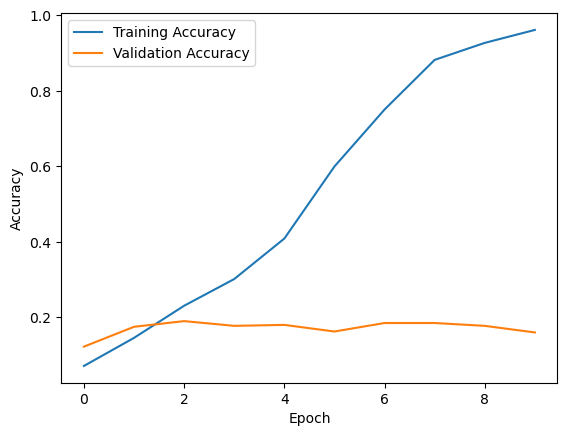

In [13]:
# Konfigurasi dasar
data_dir = "../dataset/food-20"  # path dataset
img_height, img_width = 224, 224
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/train",
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/val",
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names

num_classes = len(class_names)

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
print(f"Training Accuracy: {acc:.2f}, Validation Accuracy: {val_acc:.2f}")

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Save model
model.save("../backend/app/saved_models/baseline.h5")